## Instructions for citation:
    If you use this dataset anywhere in your work, kindly cite as the below:
"Google Play Store Apps," Feb 2019. [Online]. Available: https://www.kaggle.com/lava18/google-play-store-apps

### Context
While many public datasets (on Kaggle and the like) provide Apple App Store data, there are not many counterpart datasets available for Google Play Store apps anywhere on the web. On digging deeper, I found out that iTunes App Store page deploys a nicely indexed appendix-like structure to allow for simple and easy web scraping. On the other hand, Google Play Store uses sophisticated modern-day techniques (like dynamic page load) using JQuery making scraping more challenging.

### ontent
Each app (row) has values for catergory, rating, size, and more.

### Acknowledgements
This information is scraped from the Google Play Store. This app information would not be available without it.

### Inspiration
The Play Store apps data has enormous potential to drive app-making businesses to success. Actionable insights can be drawn for developers to work on and capture the Android market!

## EDA ON Google Play Store App dataset

In [232]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from scipy import stats

In [171]:
# load dataset 
df = pd.read_csv('googleplaystore.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Mcqueen Coloring pages,ART_AND_DESIGN,NaN,61,7.0M,"100,000+",Free,0,Everyone,Art & Design;Action & Adventure,"March 7, 2018",1.0.0,4.1 and up
1,Wrinkles and rejuvenation,BEAUTY,NaN,182,5.7M,"100,000+",Free,0,Everyone 10+,Beauty,"September 20, 2017",8.0,3.0 and up
2,Manicure - nail design,BEAUTY,NaN,119,3.7M,"50,000+",Free,0,Everyone,Beauty,"July 23, 2018",1.3,4.1 and up
3,Skin Care and Natural Beauty,BEAUTY,NaN,654,7.4M,"100,000+",Free,0,Teen,Beauty,"July 17, 2018",1.15,4.1 and up
4,"Secrets of beauty, youth and health",BEAUTY,NaN,77,2.9M,"10,000+",Free,0,Mature 17+,Beauty,"August 8, 2017",2.0,2.3 and up


In [172]:
df.shape

(10839, 13)

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10839 entries, 0 to 10838
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10839 non-null  object 
 1   Category        10839 non-null  object 
 2   Rating          9365 non-null   float64
 3   Reviews         10839 non-null  int64  
 4   Size            10839 non-null  object 
 5   Installs        10839 non-null  object 
 6   Type            10838 non-null  object 
 7   Price           10839 non-null  object 
 8   Content Rating  10839 non-null  object 
 9   Genres          10839 non-null  object 
 10  Last Updated    10839 non-null  object 
 11  Current Ver     10831 non-null  object 
 12  Android Ver     10837 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.1+ MB


_______
### Observations:
    
    We have only 2 columns as numeric data type, rest all are object data type (according to python), but we can see that 'Size', 'Installs', 'Price' are also numeric, we must convert them to numeric data type in data wrangling process.
    _____

In [174]:
# check the rating column with unique values
df['Rating'].unique()

array([nan, 5. , 4.9, 4.8, 4.7, 4.6, 4.5, 4.4, 4.3, 4.2, 4.1, 4. , 3.9,
       3.8, 3.7, 3.6, 3.5, 3.4, 3.3, 3.2, 3.1, 3. , 2.9, 2.8, 2.7, 2.6,
       2.5, 2.4, 2.3, 2.2, 2.1, 2. , 1.9, 1.8, 1.7, 1.6, 1.5, 1.4, 1.2,
       1. ])

In [175]:
# check the missing values in 'Rating ' column
df['Rating'].isnull().sum()

np.int64(1474)

In [176]:
# Check the 'Reviews' column 
df['Reviews'].value_counts().sum()

np.int64(10839)

In [177]:

df['Reviews'].value_counts()

Reviews
0       596
1       272
2       214
3       175
4       137
       ... 
1172      1
686       1
3270      1
2390      1
876       1
Name: count, Length: 6000, dtype: int64

In [178]:
df['Size'].value_counts()

Size
Varies with device    1695
11M                    198
12M                    196
14M                    194
13M                    191
                      ... 
253k                     1
240k                     1
582k                     1
976k                     1
887k                     1
Name: count, Length: 461, dtype: int64


#### Observations:

1.   "Varies with device"
2.      M
3.      k
 i want to to convert object type to interger type and for this reason remove these 3 types from size column

In [179]:
# total 'M' attech with size column values
df['Size'].loc[df['Size'].str.contains('M')].value_counts().sum()

np.int64(8828)

In [180]:
# total 'k'values from size column
df['Size'].loc[df['Size'].str.contains('k')].value_counts().sum()

np.int64(316)

In [181]:
# check total number 'Varies with device' from size column
df['Size'].loc[df['Size'].str.contains('Varies with device')].value_counts()

Size
Varies with device    1695
Name: count, dtype: int64

In [182]:
# check for total length of df for after removing M, K, Varies with device from size column
len(df)

10839

In [183]:
#let's define a function

def convert_size(size):
    if isinstance(size, str):
        if 'k' in size:
            return float(size.replace('k', "")) * 1024
        elif 'M' in size:
            return float(size.replace('M', "")) * 1024 * 1024
        elif 'Varies with device' in size:
            return np.nan
    return size
    

In [184]:
# let's apply this function
df['Size'] = df['Size'].apply(convert_size)

In [185]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Mcqueen Coloring pages,ART_AND_DESIGN,NaN,61,7340032.0,"100,000+",Free,0,Everyone,Art & Design;Action & Adventure,"March 7, 2018",1.0.0,4.1 and up
1,Wrinkles and rejuvenation,BEAUTY,NaN,182,5976883.2,"100,000+",Free,0,Everyone 10+,Beauty,"September 20, 2017",8.0,3.0 and up
2,Manicure - nail design,BEAUTY,NaN,119,3879731.2,"50,000+",Free,0,Everyone,Beauty,"July 23, 2018",1.3,4.1 and up
3,Skin Care and Natural Beauty,BEAUTY,NaN,654,7759462.4,"100,000+",Free,0,Teen,Beauty,"July 17, 2018",1.15,4.1 and up
4,"Secrets of beauty, youth and health",BEAUTY,NaN,77,3040870.4,"10,000+",Free,0,Mature 17+,Beauty,"August 8, 2017",2.0,2.3 and up


In [186]:
df['size_in_bytes'] = df['Size']

In [187]:
df.describe()

,Rating,Reviews,Size,size_in_bytes
count,9365.000000,1.083900e+04,9.144000e+03,9.144000e+03
mean,4.191703,4.441858e+05,2.256280e+07,2.256280e+07
std,0.515220,2.927894e+06,2.368725e+07,2.368725e+07
min,1.000000,0.000000e+00,8.704000e+03,8.704000e+03
25%,4.000000,3.800000e+01,5.138022e+06,5.138022e+06
50%,4.300000,2.094000e+03,1.363149e+07,1.363149e+07
75%,4.500000,5.464400e+04,3.145728e+07,3.145728e+07
max,5.000000,7.815831e+07,1.048576e+08,1.048576e+08


In [188]:
# now i want to convert size in bytes to kb
df['size_in_kb'] = df['size_in_bytes'].apply(lambda x: x/1024)

In [189]:
# now i want to convert size in bytes to MB

df['size_in_mb'] = df['size_in_bytes'].apply(lambda x: x/1024 *1024)

We have 8830 values in M units 

We have 316 values in k units

We have 1695 value in Varies with device

Let's convert the M and K units into bytes and then remove the M and K from the values and convert them into numeric data type.

In [190]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,size_in_bytes,size_in_kb,size_in_mb
0,Mcqueen Coloring pages,ART_AND_DESIGN,NaN,61,7340032.0,"100,000+",Free,0,Everyone,Art & Design;Action & Adventure,"March 7, 2018",1.0.0,4.1 and up,7340032.0,7168.0,7340032.0
1,Wrinkles and rejuvenation,BEAUTY,NaN,182,5976883.2,"100,000+",Free,0,Everyone 10+,Beauty,"September 20, 2017",8.0,3.0 and up,5976883.2,5836.8,5976883.2
2,Manicure - nail design,BEAUTY,NaN,119,3879731.2,"50,000+",Free,0,Everyone,Beauty,"July 23, 2018",1.3,4.1 and up,3879731.2,3788.8,3879731.2
3,Skin Care and Natural Beauty,BEAUTY,NaN,654,7759462.4,"100,000+",Free,0,Teen,Beauty,"July 17, 2018",1.15,4.1 and up,7759462.4,7577.6,7759462.4
4,"Secrets of beauty, youth and health",BEAUTY,NaN,77,3040870.4,"10,000+",Free,0,Mature 17+,Beauty,"August 8, 2017",2.0,2.3 and up,3040870.4,2969.6,3040870.4


In [191]:
df['Installs'].value_counts()

Installs
1,000,000+        1579
10,000,000+       1252
100,000+          1169
10,000+           1054
1,000+             907
5,000,000+         751
100+               719
500,000+           539
50,000+            479
5,000+             477
100,000,000+       409
10+                386
500+               330
50,000,000+        289
50+                205
5+                  82
500,000,000+        72
1+                  67
1,000,000,000+      58
0+                  14
0                    1
Name: count, dtype: int64

The only problem I see here is the + sign in the values, let's remove them and convert the column into numeric data type.

The total values in the Installs column are 10841 and there are no null values in the column.

However, one value 0 has no plus sign

Let's remove the plus sign + and , from the values and convert them into numeric data type

In [192]:
# i remove + sign from installed column through lambda functin
df['Installs'] = df['Installs'].apply(lambda x: x.replace('+', "") if '+' in str(x) else x )

In [193]:
# remove ',' from installed column 
df['Installs'] = df['Installs'].apply(lambda x: x.replace(',', "") if ',' in str(x) else x)

In [194]:
# convert object data type of installed column to integer 
df['Installs'] = df['Installs'].apply(lambda x: int(x))

Let's verify if the dtypes has been changes and the + and , sign has been removed


In [195]:
df.describe()

,Rating,Reviews,Size,Installs,size_in_bytes,size_in_kb,size_in_mb
count,9365.000000,1.083900e+04,9.144000e+03,1.083900e+04,9.144000e+03,9144.000000,9.144000e+03
mean,4.191703,4.441858e+05,2.256280e+07,1.546530e+07,2.256280e+07,22033.988637,2.256280e+07
std,0.515220,2.927894e+06,2.368725e+07,8.503322e+07,2.368725e+07,23132.080081,2.368725e+07
min,1.000000,0.000000e+00,8.704000e+03,0.000000e+00,8.704000e+03,8.500000,8.704000e+03
25%,4.000000,3.800000e+01,5.138022e+06,1.000000e+03,5.138022e+06,5017.600000,5.138022e+06
50%,4.300000,2.094000e+03,1.363149e+07,1.000000e+05,1.363149e+07,13312.000000,1.363149e+07
75%,4.500000,5.464400e+04,3.145728e+07,5.000000e+06,3.145728e+07,30720.000000,3.145728e+07
max,5.000000,7.815831e+07,1.048576e+08,1.000000e+09,1.048576e+08,102400.000000,1.048576e+08


In [196]:
print(df['Installs'].max())
print(df['Installs'].min())
print(round(df['Installs'].mean(), 2))

1000000000
0
15465304.32


In [197]:
bins = [-1, 0, 10, 1000, 10000, 100000, 1000000, 100000000, 1000000000]
labels = ['no', 'very low', 'low', 'Moderate', 'More than moderate', 'High', 'Very High', 'Top Notch']
df['Installs_category'] = pd.cut(df['Installs'], bins=bins, labels=labels)

In [198]:
df['Installs_category'].value_counts()

Installs_category
Very High             2701
low                   2161
High                  2118
More than moderate    1648
Moderate              1531
very low               535
Top Notch              130
no                      15
Name: count, dtype: int64

## price column    

In [199]:
df['Price'].unique()

array(['0', '$1.49', '$2.99', '$3.99', '$1.00', '$24.99', '$14.99',
       '$74.99', '$0.99', '$5.99', '$39.99', '$2.49', '$2.00', '$25.99',
       '$1.99', '$9.99', '$19.99', '$5.00', '$13.99', '$19.90', '$4.85',
       '$46.99', '$109.99', '$154.99', '$4.80', '$8.99', '$1.96', '$5.49',
       '$4.99', '$29.99', '$8.49', '$2.60', '$28.99', '$200.00', '$89.99',
       '$30.99', '$3.61', '$394.99', '$1.26', '$399.99', '$6.49', '$1.04',
       '$1.75', '$3.04', '$6.99', '$4.49', '$2.50', '$3.49', '$10.00',
       '$7.49', '$15.99', '$2.59', '$19.40', '$3.90', '$79.99', '$3.88',
       '$17.99', '$18.99', '$14.00', '$7.99', '$4.29', '$12.99', '$11.99',
       '$1.76', '$1.59', '$2.95', '$1.97', '$16.99', '$1.70', '$3.08',
       '$9.00', '$1.50', '$3.02', '$1.61', '$37.99', '$2.90', '$1.20',
       '$4.84', '$1.29', '$3.28', '$3.95', '$4.77', '$299.99', '$10.99',
       '$400.00', '$389.99', '$33.99', '$15.46', '$4.60', '$2.56',
       '$379.99', '$4.59'], dtype=object)

In [200]:
# check that values in price column how many values in which '$' included
df['Price'].loc[df['Price'].str.contains('\$')].value_counts().sum()

np.int64(800)

In [201]:
# now remove this $ from price column 800 values
df['price'] = df['Price'].apply(lambda x: x.replace('$', "")if '$' in str(x) else x)

In [202]:
df['price'].value_counts()

price
0         10039
0.99        148
2.99        129
1.99         73
4.99         72
          ...  
15.46         1
4.60          1
2.56          1
379.99        1
4.59          1
Name: count, Length: 92, dtype: int64

In [203]:
# This code counts the number of values in the 'Price' column which contains 0 but does not contain $ sign
df['Price'].loc[(df['Price'].str.contains('0')) & (~df['Price'].str.contains('\$'))].value_counts().sum()

np.int64(10039)

In [204]:
df['price'] =  df['price'].apply(lambda x: float(x))

In [205]:
print(f"The minimum price of the app {df['price'].min()} $")

print(f"The maximum price of the app {df['price'].max()} $")

The minimum price of the app 0.0 $
The maximum price of the app 400.0 $


In [207]:
df.drop(['Size', 'Price'],  axis=1, inplace=True)

In [214]:
df.drop('size_in_kb', axis=1 , inplace=True)

### 2.1. Descriptive Statistics


In [215]:
df.describe()

,Rating,Reviews,Installs,size_in_bytes,size_in_mb,price
count,9365.000000,1.083900e+04,1.083900e+04,9.144000e+03,9.144000e+03,10839.000000
mean,4.191703,4.441858e+05,1.546530e+07,2.256280e+07,2.256280e+07,1.027463
std,0.515220,2.927894e+06,8.503322e+07,2.368725e+07,2.368725e+07,15.950436
min,1.000000,0.000000e+00,0.000000e+00,8.704000e+03,8.704000e+03,0.000000
25%,4.000000,3.800000e+01,1.000000e+03,5.138022e+06,5.138022e+06,0.000000
50%,4.300000,2.094000e+03,1.000000e+05,1.363149e+07,1.363149e+07,0.000000
75%,4.500000,5.464400e+04,5.000000e+06,3.145728e+07,3.145728e+07,0.000000
max,5.000000,7.815831e+07,1.000000e+09,1.048576e+08,1.048576e+08,400.000000


## Observations:
Now, we have only 6 columns as numeric data type.

We can observe their descriptive statistics. and make tons of observations as per our hypotheses.

We can see that the Rating column has a minimum value of 1 and a maximum value of 5, which is the range of rating, and the mean is 4.19 which is a good rating. On an average people give this rating.

We can see that the Reviews column has a minimum value of 0 and a maximum value of 78,158,306 78+ Millions, which is the range of reviews, and the mean is 444,111.93 which is a good number of reviews. On an average people give this number of reviews to the apps. But it does not make sense to us, as we have different categories of apps.

Similarly, we can observe the other columns as well.

Therefore, the most important thing is to classify as app based on the correlation matrix and then observe the descriptive statistics of the app category and number of installs, reviews, ratings, etc.

But even before that we have to think about the missing values in the dataset.

###  2.2. Dealing with the missing values
Dealing with the missing values is one of the most important part of the data wrangling process, we must deal with the missing values in order to get the correct insights from the data.



In [216]:
# count the total number of values in columns
df.isnull().sum().sort_values(ascending=False)

size_in_mb           1695
size_in_bytes        1695
Rating               1474
Current Ver             8
Android Ver             2
Type                    1
App                     0
Content Rating          0
Installs                0
Reviews                 0
Category                0
Genres                  0
Last Updated            0
Installs_category       0
price                   0
dtype: int64

In [217]:
# count the percentage of missing values in each column
df.isnull().sum().sort_values(ascending=False) / len(df) * 100 

size_in_mb           15.637974
size_in_bytes        15.637974
Rating               13.599041
Current Ver           0.073808
Android Ver           0.018452
Type                  0.009226
App                   0.000000
Content Rating        0.000000
Installs              0.000000
Reviews               0.000000
Category              0.000000
Genres                0.000000
Last Updated          0.000000
Installs_category     0.000000
price                 0.000000
dtype: float64

<Axes: >

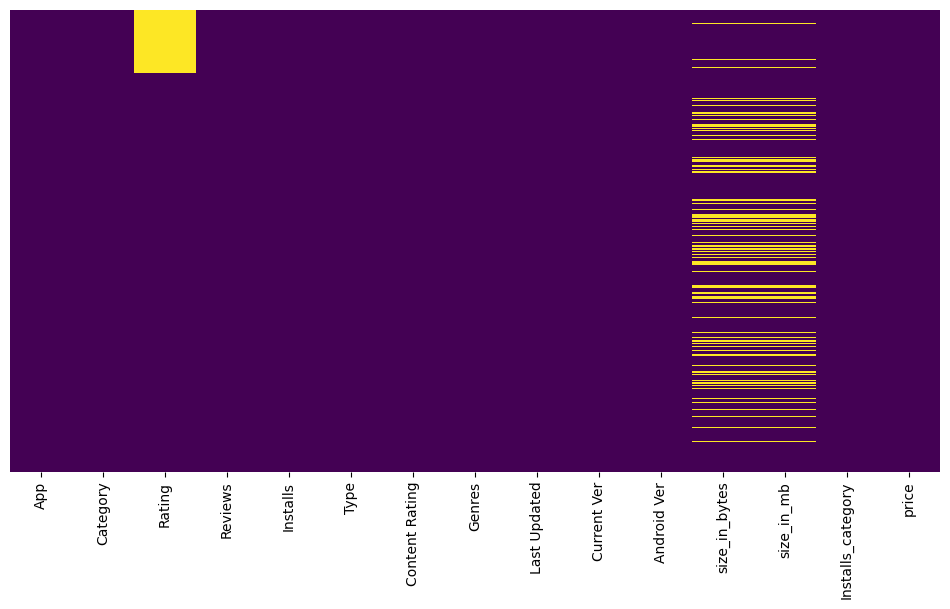

In [220]:
# make a figure size
plt.figure( figsize=(12, 6))
#plot the null values in each column
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

Text(0.5, 1.0, 'Percentage of Missing Values in each Column')

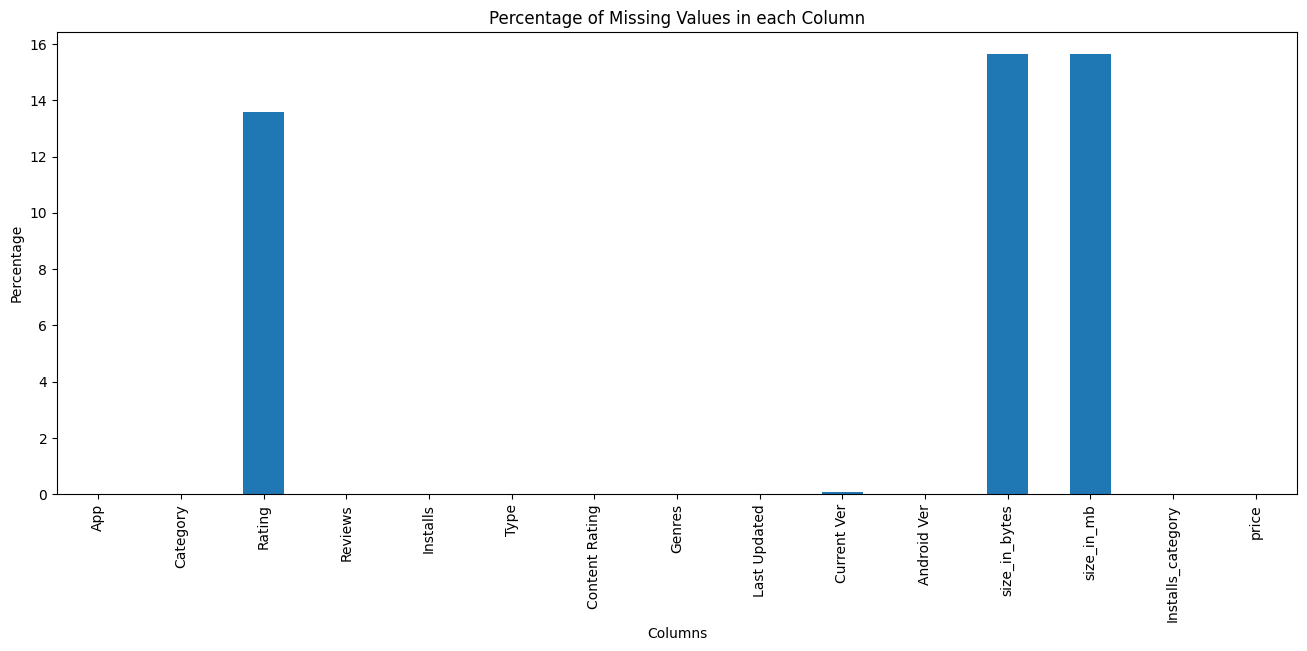

In [221]:

# make figure size
plt.figure(figsize=(16, 6))
# plot the null values by their percentage in each column
missing_percentage = df.isnull().sum()/len(df)*100
missing_percentage.plot(kind='bar')
# add the labels
plt.xlabel('Columns')
plt.ylabel('Percentage')
plt.title('Percentage of Missing Values in each Column')

Let's plot the missing values other than 'Rating', 'Size_in_bytes' and 'Size_in_Mb' column

We have missing percentage columns other than rating having less than one percent of missing values, we will plot them as follows:

Text(0.5, 1.0, 'Percentage of Missing Values in each Column without Rating column')

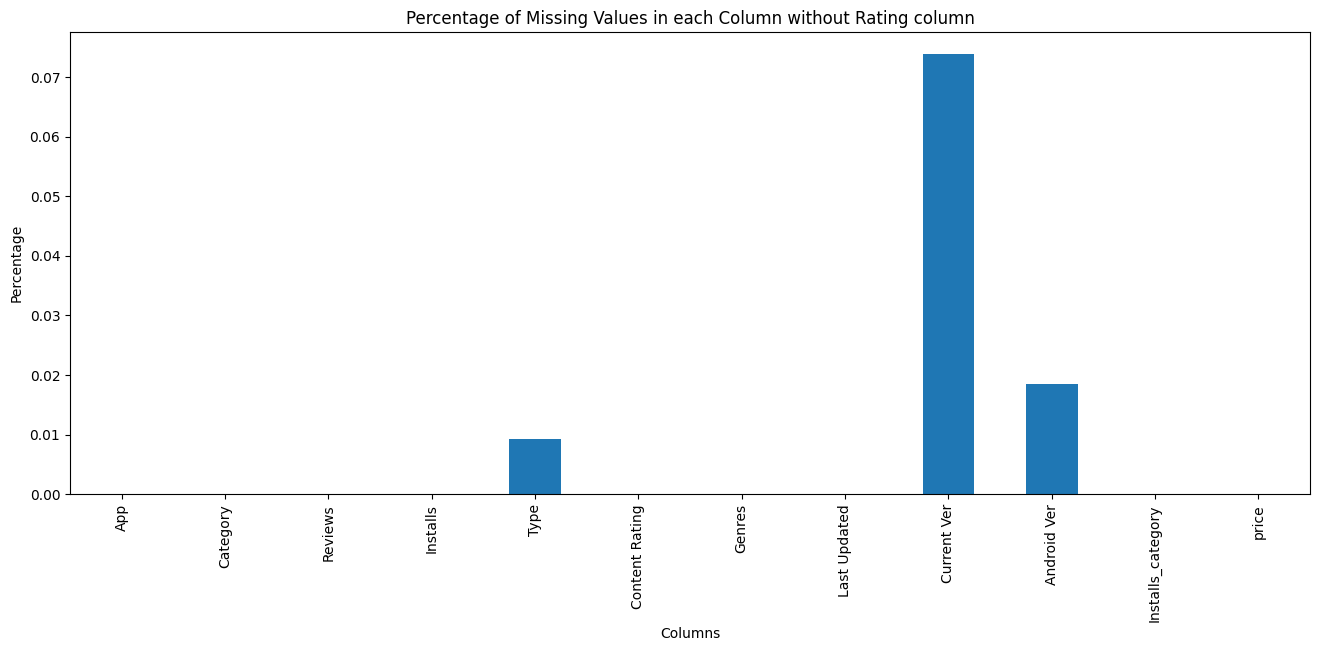

In [223]:
plt.figure(figsize=(16, 6)) # make figure size
missing_percentage[missing_percentage<1].plot(kind='bar') # plot the null values by their percentage in each column
plt.xlabel('Columns') # add the x-axis labels
plt.ylabel('Percentage') # add the labels for y-axis
plt.title('Percentage of Missing Values in each Column without Rating column')  # add the title for the plot

### Observations:
We have 1695 missing values in the 'Size_in_bytes' and 'Size_in_Mb' columns, which is 15.6% of the total values in the column.

We have 1474 missing values in the 'Rating' column, which is 13.6% of the total values in the column.

We have 8 missing value in the 'Current Ver' column, which is 0.07% of the total values in the column.

We have 2 missing values in the 'Android Ver' column, which is 0.01% of the total values in the column.
____
#### 2.3. Dealing with the missing values
We can not impute the Rating column as is is directly linked with the installation column.
To test this Hypothesis we need to plot the Rating column with the Installs and Size columns and statistically test it using pearson correlation test.
___
Let's run the correlations

In [225]:
df.describe()

,Rating,Reviews,Installs,size_in_bytes,size_in_mb,price
count,9365.000000,1.083900e+04,1.083900e+04,9.144000e+03,9.144000e+03,10839.000000
mean,4.191703,4.441858e+05,1.546530e+07,2.256280e+07,2.256280e+07,1.027463
std,0.515220,2.927894e+06,8.503322e+07,2.368725e+07,2.368725e+07,15.950436
min,1.000000,0.000000e+00,0.000000e+00,8.704000e+03,8.704000e+03,0.000000
25%,4.000000,3.800000e+01,1.000000e+03,5.138022e+06,5.138022e+06,0.000000
50%,4.300000,2.094000e+03,1.000000e+05,1.363149e+07,1.363149e+07,0.000000
75%,4.500000,5.464400e+04,5.000000e+06,3.145728e+07,3.145728e+07,0.000000
max,5.000000,7.815831e+07,1.000000e+09,1.048576e+08,1.048576e+08,400.000000


<Axes: >

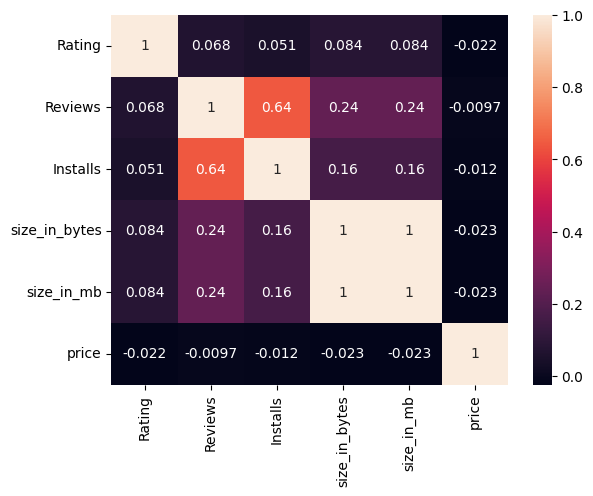

In [231]:
# make the heatmap for checking coorelation of numeric columns
plt.Figure(figsize=( 14, 6))
numeric_cols = ['Rating', 'Reviews', 'Installs', 'size_in_bytes', 'size_in_mb', 'price'] # make a numeric column list
sns.heatmap(df[numeric_cols].corr(), annot=True) # plot the correlation matrix

In [233]:
# we can calculate the pearson correlation coefficient using scipy as well as follows

# this is to install scipy if you have not done it before
# pip install scipy 
from scipy import stats

# remove rows containing NaN or infinite values (Important to calculate Pearson's R)
df_clean = df.dropna()

# calculate Pearson's R between Rating and Installs
pearson_r, _ = stats.pearsonr(df_clean['Reviews'], df_clean['Installs'])
print(f"Pearson's R between Reviews and Installs: {pearson_r:.4f}")

Pearson's R between Reviews and Installs: 0.6262
